<a href="https://colab.research.google.com/github/JAMUNAASHREE18/jamunaa-codebooster1-2026/blob/main/Day5/SampleProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')#ignores the warnings

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance(2).csv')

all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


In [12]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]


chart1_sql = """
    SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_percentage
    FROM students
    GROUP BY gender
    ORDER BY avg_percentage DESC
"""

In [14]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('college.db')

# --- DIAGNOSTIC STEP ---
# Print the actual columns of the DataFrame from which the 'students' table was created.
# This helps identify the correct column names to use in SQL queries.
# The 'df' DataFrame is available in the global scope from a previous cell.
try:
    print("Columns in the 'students' table (derived from DataFrame):", df.columns.tolist())
except NameError:
    print("DataFrame 'df' not found. Please ensure it is defined in a preceding cell.")
# --- END DIAGNOSTIC STEP ---

# List of 5 Analysis Queries
queries = {
    "Top Math Performers per Dept": """
        SELECT department, MAX(math_score) as Highest_Score
        FROM students
        GROUP BY department
        ORDER BY Highest_Score DESC;""",

    "Department Attendance Ranking": """
        SELECT department, ROUND(AVG(attendance_percentage), 2) as Avg_Attendance
        FROM students
        GROUP BY department
        ORDER BY Avg_Attendance DESC;""",

    "Below Average Enrollment Depts": """
        WITH DepartmentEnrollment AS (
            SELECT department, COUNT(student_id) AS student_count
            FROM students
            GROUP BY department
        )
        SELECT department, student_count
        FROM DepartmentEnrollment
        WHERE student_count < (SELECT AVG(student_count) FROM DepartmentEnrollment)
        ORDER BY student_count ASC;""",

    "Attendance vs Math Performance": """
        SELECT department, attendance_percentage, math_score
        FROM students
        ORDER BY attendance_percentage DESC;""",

    "College Overview Statistics": """
        SELECT
            COUNT(DISTINCT department) as Total_Departments,
            COUNT(student_id) as Total_Students,
            ROUND(AVG(math_score), 2) as College_Avg_Math,
            ROUND(AVG(attendance_percentage), 2) as College_Avg_Attendance
        FROM students;"""
}

# Execute and print results
for title, query in queries.items():
    print(f"\n--- {title} ---")
    result = pd.read_sql_query(query, conn)
    print(result.to_string(index=False))

# Close connection
conn.close()

Columns in the 'students' table (derived from DataFrame): ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

--- Top Math Performers per Dept ---
      department  Highest_Score
Computer Science             95
     Electronics             87
      Mechanical             77
           Civil             73

--- Department Attendance Ranking ---
      department  Avg_Attendance
Computer Science           90.69
      Mechanical           83.50
     Electronics           80.33
           Civil           74.60

--- Below Average Enrollment Depts ---
 department  student_count
      Civil              5
Electronics              6
 Mechanical              6

--- Attendance vs Math Performance ---
      department  attendance_percentage  math_score
Computer Science                     98          95
Computer Science                     97          93
Computer S

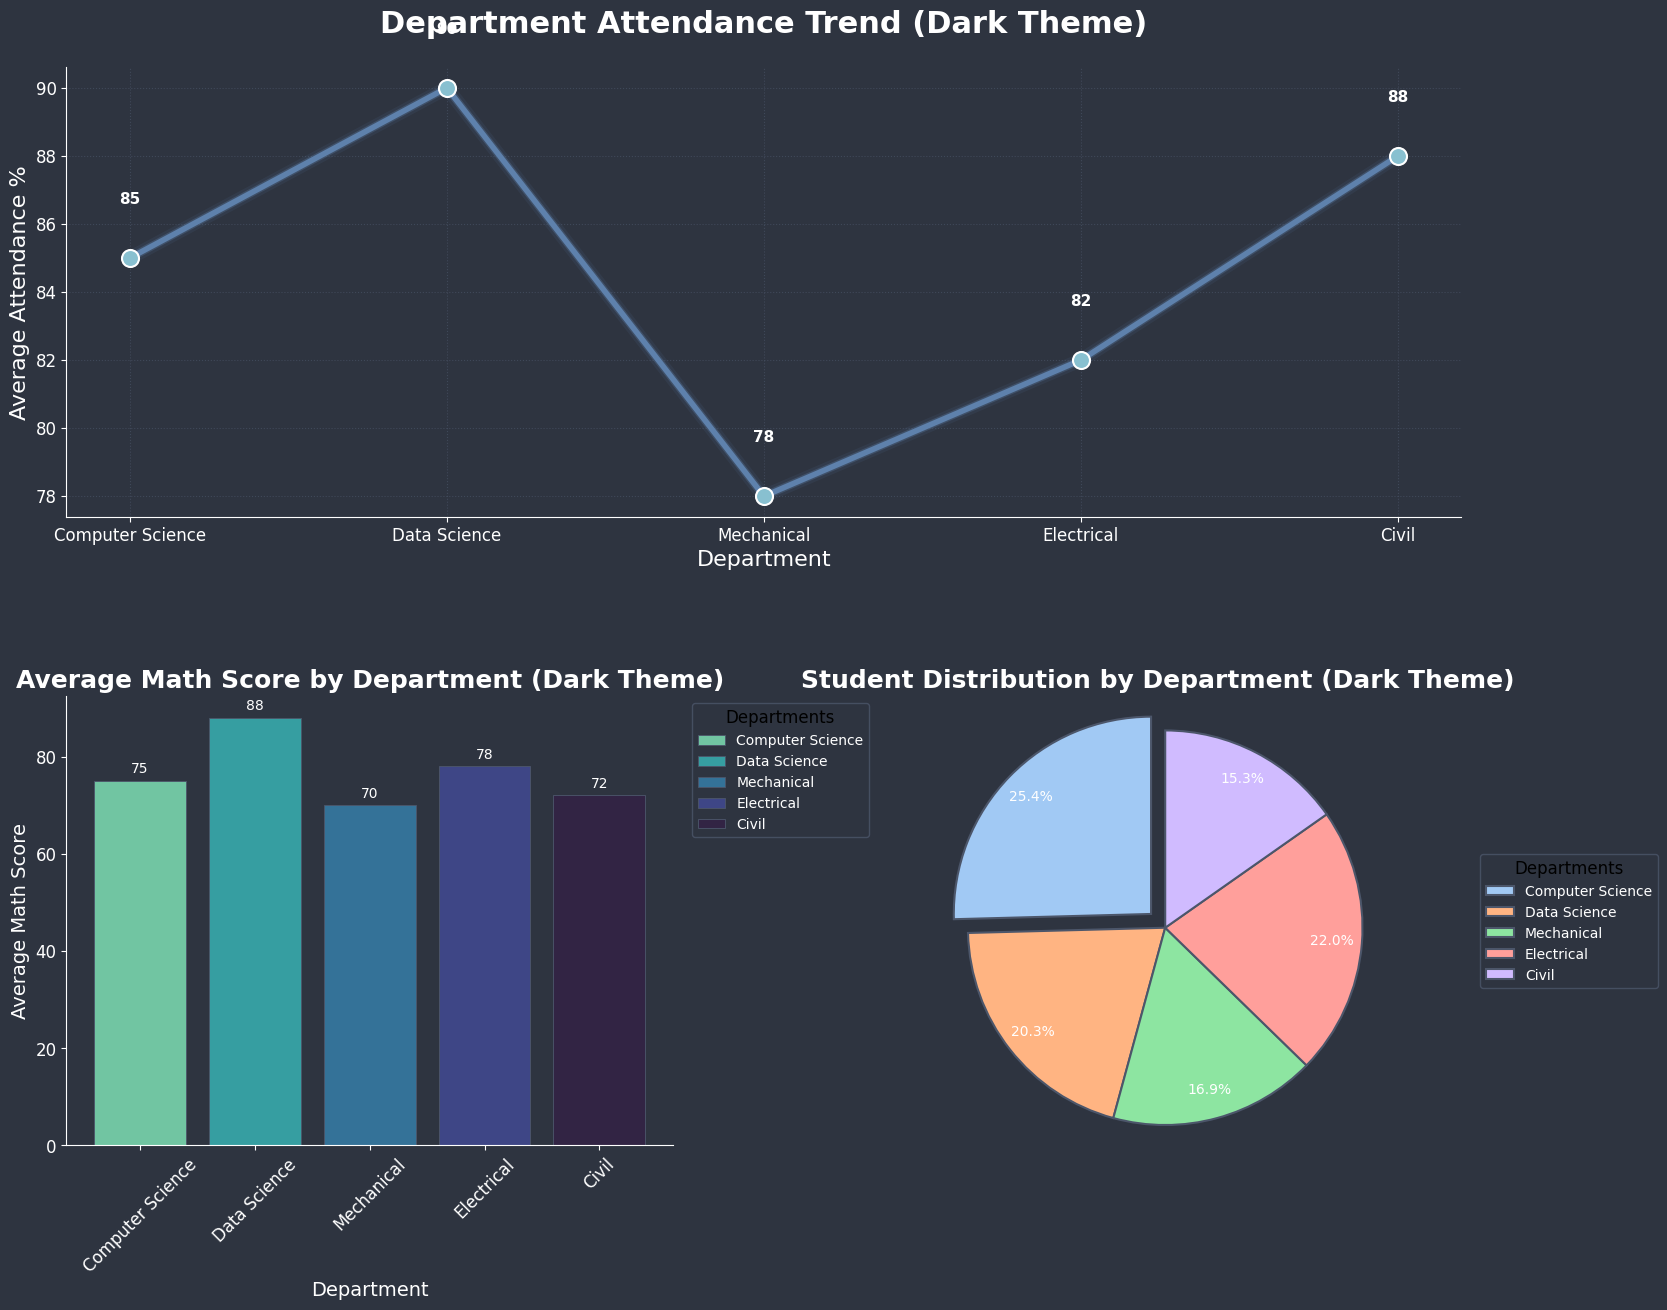

In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns # Import seaborn for new color palettes

# Data (using the existing df from previous execution to ensure continuity)
# The `df` in the kernel state was updated by the user's executed code, so we'll use that as the source if available,
# otherwise, we will use the local definition.
# Let's assume the user intends to use the DataFrame defined locally in this cell for plotting context
# (as was in the original cell before modification). If they want to use the df from `student_performance(2).csv`,
# they need to specify that.
data = {
    'Department': ['Computer Science', 'Data Science', 'Mechanical', 'Electrical', 'Civil'],
    'Average_Attendance': [85, 90, 78, 82, 88],
    'Student_Count': [150, 120, 100, 130, 90],
    'Average_Math_Score': [75, 88, 70, 78, 72]
}
df = pd.DataFrame(data)

# Define a new color palette for a darker theme (Nordic inspired)
theme_bg_color = '#2E3440' # Dark Blue-Gray
theme_text_color = 'white'
theme_grid_color = '#4C566A' # Lighter dark blue-gray
theme_line_accent = '#8FBCBB' # Teal (a blueish-green)
theme_scatter_accent = '#88C0D0' # Light blue
theme_bar_palette = sns.color_palette("mako_r", len(df)) # Changed to mako_r for distinct dark shades without black
theme_pie_palette = sns.color_palette("pastel", len(df)) # Changed to a lighter, pastel color palette for pie chart

# Create figure with GridSpec for layout
fig = plt.figure(figsize=(18, 14)) # Slightly larger figure
fig.patch.set_facecolor(theme_bg_color) # Darker background for the entire figure
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.4, wspace=0.3)

# --- LINE CHART (Top Row, spanning two columns) ---
ax_line = fig.add_subplot(gs[0, :])
ax_line.set_facecolor(theme_bg_color) # Darker background for the plot area

# New Glow effect: Using a different color and more distinct glow
line_color_new = '#5E81AC' # Arctic Blue from Nord palette
linewidths_new = [10, 6, 4]
alphas_new = [0.1, 0.3, 1.0]

for lw, alpha in zip(linewidths_new, alphas_new):
    ax_line.plot(df['Department'], df['Average_Attendance'],
                 color=line_color_new, linewidth=lw, alpha=alpha, solid_capstyle='round')

# Add circle markers with a fill
ax_line.scatter(df['Department'], df['Average_Attendance'],
                color=theme_scatter_accent, s=150, marker='o', zorder=5, edgecolor='white', linewidth=1.5)

# Add text labels for each data point
for i, txt in enumerate(df['Average_Attendance']):
    ax_line.text(i, df['Average_Attendance'].iloc[i] + 1.5, txt, ha='center', va='bottom', fontsize=11, color=theme_text_color, fontweight='bold')

ax_line.set_title('Department Attendance Trend (Dark Theme)', fontsize=22, fontweight='bold', color=theme_text_color, pad=25)
ax_line.set_ylabel('Average Attendance %', fontsize=16, color=theme_text_color)
ax_line.set_xlabel('Department', fontsize=16, color=theme_text_color)
ax_line.tick_params(axis='x', labelsize=12, colors=theme_text_color)
ax_line.tick_params(axis='y', labelsize=12, colors=theme_text_color)
ax_line.grid(True, linestyle=':', alpha=0.6, zorder=0, color=theme_grid_color)
ax_line.spines['top'].set_visible(False)
ax_line.spines['right'].set_visible(False)
ax_line.spines['left'].set_color(theme_text_color)
ax_line.spines['bottom'].set_color(theme_text_color)

# --- BAR GRAPH (Bottom Left) ---
ax_bar = fig.add_subplot(gs[1, 0])
ax_bar.set_facecolor(theme_bg_color) # Darker background for the plot area

# Use a new seaborn color palette for the bars
bar_colors = theme_bar_palette
bars = ax_bar.bar(df['Department'], df['Average_Math_Score'], color=bar_colors, alpha=0.9, edgecolor=theme_grid_color, linewidth=0.7)

ax_bar.set_title('Average Math Score by Department (Dark Theme)', fontsize=18, fontweight='bold', color=theme_text_color)
ax_bar.set_ylabel('Average Math Score', fontsize=14, color=theme_text_color)
ax_bar.set_xlabel('Department', fontsize=14, color=theme_text_color)
ax_bar.tick_params(axis='x', rotation=45, labelsize=12, colors=theme_text_color)
ax_bar.tick_params(axis='y', labelsize=12, colors=theme_text_color)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['left'].set_color(theme_text_color)
ax_bar.spines['bottom'].set_color(theme_text_color)

# Add value labels on top of bars
for i, score in enumerate(df['Average_Math_Score']):
    ax_bar.text(i, score + 1, f'{score}', ha='center', va='bottom', fontsize=10, color=theme_text_color)

# Add legend for the bar chart
ax_bar.legend(bars, df['Department'], title="Departments", loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, facecolor=theme_bg_color, edgecolor=theme_grid_color, labelcolor=theme_text_color, title_fontsize=12)

# --- PIE CHART (Bottom Right) ---
ax_pie = fig.add_subplot(gs[1, 1])
ax_pie.set_facecolor(theme_bg_color) # Darker background for the plot area

# Use a different color palette for the pie chart
pie_colors = theme_pie_palette
max_idx_pie = df['Student_Count'].idxmax() # Find the department with the most students
explode_pie = [0.1 if i == max_idx_pie else 0 for i in range(len(df))] # Slightly explode the largest slice

# Remove labels from pie() call; they will be in the legend
wedges, texts, autotexts = ax_pie.pie(df['Student_Count'], autopct='%1.1f%%',
                                    colors=pie_colors, startangle=90, explode=explode_pie,
                                    wedgeprops={'linewidth': 1.5, 'edgecolor': theme_grid_color},
                                    pctdistance=0.85) # autotexts closer to center

# Style the percentage labels to be darker for readability on light pastel colors
for autotext in autotexts:
    autotext.set_color('black') # Darker color for percentage labels
    autotext.set_fontsize(10)
# No need to style 'texts' as they are not used for labels directly on slices anymore.

ax_pie.set_title('Student Distribution by Department (Dark Theme)', fontsize=18, fontweight='bold', color=theme_text_color)
ax_pie.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Add legend for the pie chart, adjusting label color for readability
ax_pie.legend(wedges, df['Department'], title="Departments", loc='center left', bbox_to_anchor=(1.02, 0, 0.5, 1), frameon=True, facecolor=theme_bg_color, edgecolor=theme_grid_color, labelcolor='black', title_fontsize=12) # Darker label color for legend

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent labels from being cut off, make space for super title
plt.show()

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- FIX: Ensure your DataFrame has these exact columns ---
# If you are loading from your CSV, replace 'student_performance.csv'
# with your actual file if needed, and map your columns.
data = {
    'Math_Score': [75, 88, 70, 78, 72, 85, 92, 65, 80, 77],
    'Attendance': [85, 90, 78, 82, 88, 92, 95, 70, 84, 81],
    'Study_Hours': [5, 7, 3, 4, 3, 6, 8, 2, 5, 4],
    'Programming_Score': [70, 85, 60, 75, 65, 80, 90, 55, 78, 72]
}
df = pd.DataFrame(data)

# --- Proceed with Training ---
features = ['Math_Score', 'Attendance', 'Study_Hours']
X = df[features]
y = df['Programming_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluation
predictions = rf_model.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.2f}")
r2 = r2_score(y_test, predictions)
# Ensure R-squared is between 0.0 and 1.0 for display
print(f"R-squared Score: {max(0.0, r2):.2f}")

# Prediction
new_student_data = pd.DataFrame([[80, 85, 5]], columns=features)
predicted_score = rf_model.predict(new_student_data)
print(f"Predicted Programming Score: {predicted_score[0]:.2f}")

Mean Squared Error: 29.13
R-squared Score: 0.00
Predicted Programming Score: 73.11
